In [42]:
# ===============================================
# BASIC SETUP: GIT Auth and mounting google drive
# ================================================

from google.colab import drive
import sys

# Standard mount to access the config file initially
drive.mount('/content/drive')
sys.path.append('/content/drive/MyDrive/Group 1/Room-Occupancy-Detection/src')

from utils.config import initialize_project
initialize_project()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Authenticated as: Ande404
Working Directory: /content/drive/.shortcut-targets-by-id/1yYMYQP42V95jrAfCLhvSv1wAR0w7j8iP/Big-data-group-1/Room-Occupancy-Detection


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
# data inspection
df = pd.read_csv("data/raw/datatraining.txt")
df.head()

,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
1,2015-02-04 17:51:00,23.18,27.2720,426.0,721.25,0.004793,1
2,2015-02-04 17:51:59,23.15,27.2675,429.5,714.00,0.004783,1
3,2015-02-04 17:53:00,23.15,27.2450,426.0,713.50,0.004779,1
4,2015-02-04 17:54:00,23.15,27.2000,426.0,708.25,0.004772,1
5,2015-02-04 17:55:00,23.10,27.2000,426.0,704.50,0.004757,1


In [17]:
# number of rows and columns
df.shape

(8143, 7)

In [14]:
# checking for column types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8143 entries, 1 to 8143
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           8143 non-null   object 
 1   Temperature    8143 non-null   float64
 2   Humidity       8143 non-null   float64
 3   Light          8143 non-null   float64
 4   CO2            8143 non-null   float64
 5   HumidityRatio  8143 non-null   float64
 6   Occupancy      8143 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 767.0+ KB


In [13]:
# check of null values
df.isnull().sum()

,0
date,0
Temperature,0
Humidity,0
Light,0
CO2,0
HumidityRatio,0
Occupancy,0


In [18]:
# checking for duplicate values
df.duplicated().sum()

np.int64(0)

In [19]:
df["Occupancy"].value_counts()
df["Occupancy"].value_counts(normalize=True)

,proportion
Occupancy,
0,0.78767
1,0.21233


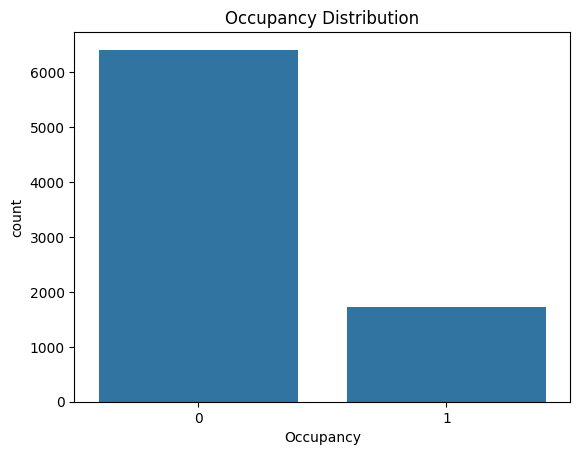

In [20]:
sns.countplot(x="Occupancy", data=df)
plt.title("Occupancy Distribution")
plt.show()

In [22]:
df.describe() # summary statistics

,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
count,8143.000000,8143.000000,8143.000000,8143.000000,8143.000000,8143.000000
mean,20.619084,25.731507,119.519375,606.546243,0.003863,0.212330
std,1.016916,5.531211,194.755805,314.320877,0.000852,0.408982
min,19.000000,16.745000,0.000000,412.750000,0.002674,0.000000
25%,19.700000,20.200000,0.000000,439.000000,0.003078,0.000000
50%,20.390000,26.222500,0.000000,453.500000,0.003801,0.000000
75%,21.390000,30.533333,256.375000,638.833333,0.004352,0.000000
max,23.180000,39.117500,1546.333333,2028.500000,0.006476,1.000000


In [23]:
df.groupby("Occupancy")[["Temperature", "Humidity", "Light", "CO2", "HumidityRatio"]].mean()

,Temperature,Humidity,Light,CO2,HumidityRatio
Occupancy,,,,,
0,20.334931,25.349685,27.776442,490.320312,0.003730
1,21.673192,27.147938,459.854347,1037.704786,0.004355


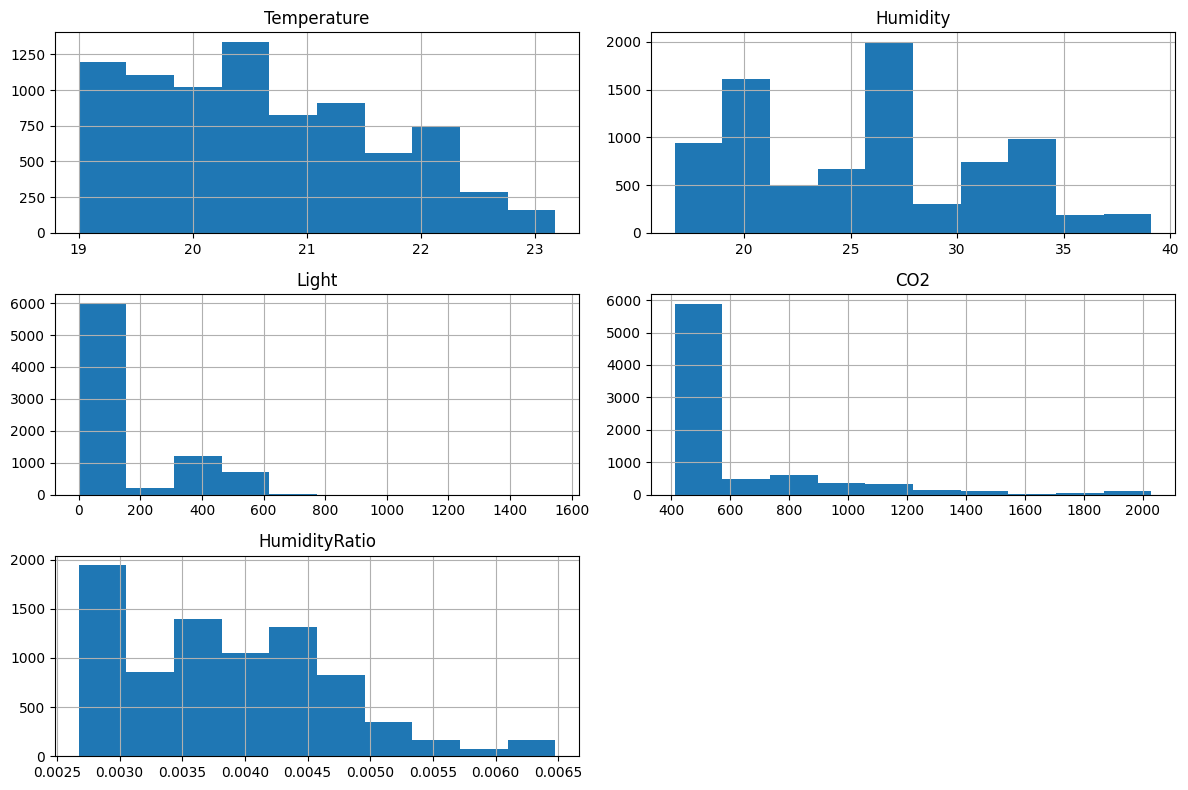

In [24]:
df[["Temperature", "Humidity", "Light", "CO2", "HumidityRatio"]].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

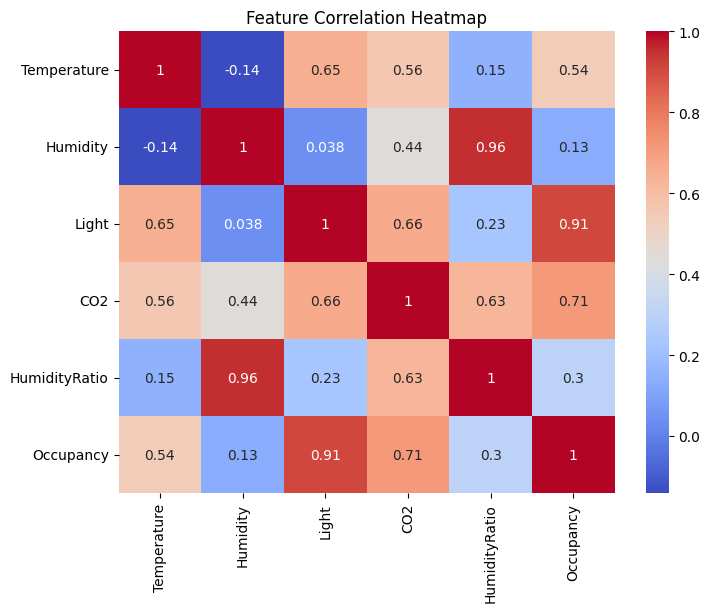

In [25]:
plt.figure(figsize=(8,6))
sns.heatmap(df.drop(columns=["date"]).corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

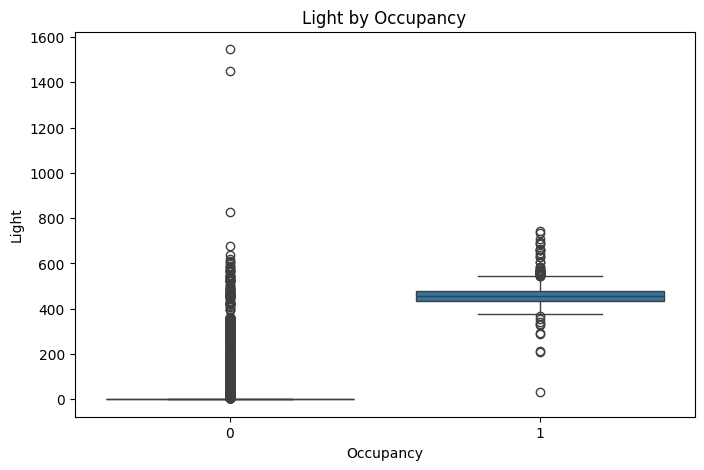

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Occupancy", y="Light", data=df)
plt.title("Light by Occupancy")
plt.show()

In [27]:
features = ["Temperature", "Humidity", "Light", "CO2", "HumidityRatio"]
target = "Occupancy"
X = df[features]
y = df[target]

In [28]:
# spliting the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [29]:
# Training the first baseline model using Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [30]:
# make predicitions
y_pred = model.predict(X_test)


In [31]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9846531614487416
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1283
           1       0.94      0.99      0.96       346

    accuracy                           0.98      1629
   macro avg       0.97      0.99      0.98      1629
weighted avg       0.99      0.98      0.98      1629

[[1262   21]
 [   4  342]]


The model achieves high accuracy, indicating that environmental sensor data is predictive of room occupancy. The model performs particularly well on detecting occupied rooms, likely due to strong signals from light and CO₂ levels.

In [34]:
# identifying the most important features for prediction
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

coefficients

,Feature,Coefficient
2,Light,0.021011
3,CO2,0.006351
1,Humidity,-0.040445
4,HumidityRatio,-0.100327
0,Temperature,-1.418762


In [35]:
# in the previous model we didnt scale our features, each feature had its own scale
# when dealing with logistic regression all features in the dataset must be on the same scale for accurate results
# here we are now scalling the features and then re-fitting the model
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [36]:
# identifying the most important features for prediction
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

coefficients

,Feature,Coefficient
2,Light,3.953450
3,CO2,1.928491
1,Humidity,0.019774
4,HumidityRatio,-0.240381
0,Temperature,-1.299701


from this we can conclude that light and CO2 are the most important predictors for occupancy in a room

In [39]:
# Random Forest Model
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

RF Accuracy: 0.994475138121547
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1283
           1       0.98      1.00      0.99       346

    accuracy                           0.99      1629
   macro avg       0.99      1.00      0.99      1629
weighted avg       0.99      0.99      0.99      1629



In [40]:
# Comparing the Models
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred),
    "Random Forest": accuracy_score(y_test, rf_pred)
}

results

{'Logistic Regression': 0.9846531614487416, 'Random Forest': 0.994475138121547}

Random Forest outperformed Logistic Regression, indicating nonlinear relationships between environmental features and occupancy.


In [41]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
2,Light,0.595952
3,CO2,0.250519
0,Temperature,0.094084
4,HumidityRatio,0.034408
1,Humidity,0.025038


We extract the most important features for prediction for the random forest model and we can see that the most important features are:


1.   Light
2.   C02
3.   temperature

